In [705]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [706]:
df=pd.read_csv("placement.csv")

In [707]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [708]:
df.shape

(200, 2)

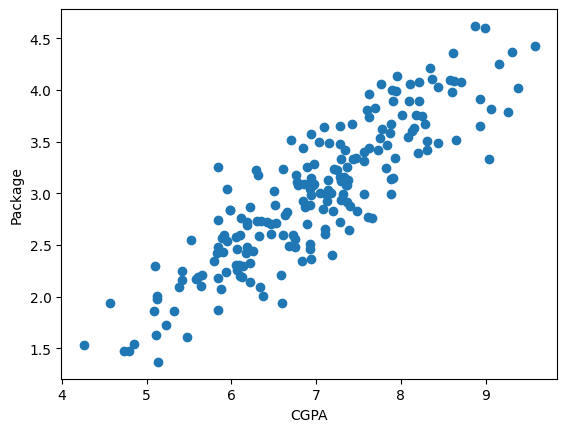

In [709]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package') 
plt.show()

In [710]:
X=df.iloc[:,0:1]
X


,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [711]:
y=df.iloc[:,-1]
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [712]:
from sklearn.model_selection import train_test_split

In [713]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [714]:
from sklearn.linear_model import LinearRegression

In [715]:
lr=LinearRegression()

In [716]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [717]:
y_pred=lr.predict(X_test)

In [718]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score

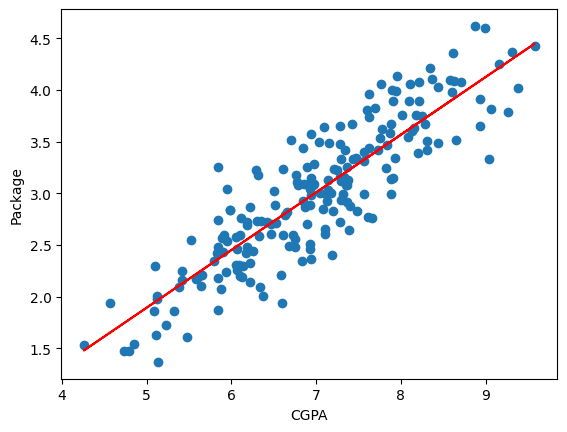

In [719]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.show()

In [720]:
MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RSME=np.sqrt(MSE)
R2=r2_score(y_test,y_pred)

In [721]:
print("Mean Absolute Error:",MAE)
print("Mean Squared Error:",MSE)
print("Root Mean Squared Error:",RSME)
print("R2 Score:",R2)     

Mean Absolute Error: 0.2884710931878175
Mean Squared Error: 0.12129235313495527
Root Mean Squared Error: 0.34827051717731616
R2 Score: 0.780730147510384


# Adjusted R2 Score

In [722]:
X_test.shape

(40, 1)

In [723]:
1-(1-R2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7749598882343415

### Giving an Irrelevant feature

In [724]:
df1=df.copy()
df1.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [725]:
df1['Random_Feature']=np.random.random(200)
df1=df1[['cgpa','Random_Feature','package']]
df1.head()

,cgpa,Random_Feature,package
0,6.89,0.125969,3.26
1,5.12,0.203150,1.98
2,7.82,0.188397,3.25
3,7.42,0.386379,3.67
4,6.94,0.526131,3.57


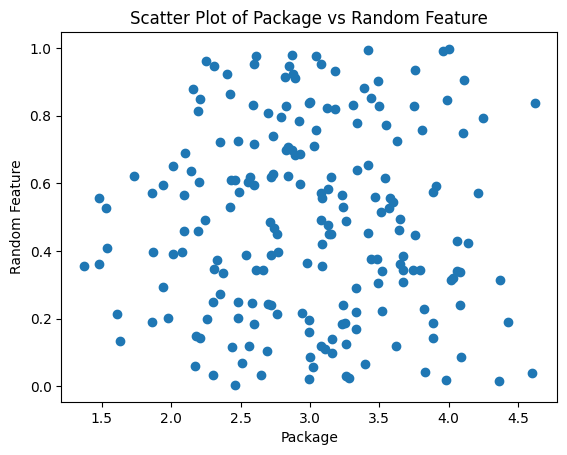

In [726]:
plt.scatter(df1['package'],df1['Random_Feature'])
plt.xlabel('Package')
plt.ylabel('Random Feature')
plt.title('Scatter Plot of Package vs Random Feature')
plt.show()

In [727]:
X = df1.iloc[:,:2]
y = df1.iloc[:, -1]

In [728]:
X

,cgpa,Random_Feature
0,6.89,0.125969
1,5.12,0.203150
2,7.82,0.188397
3,7.42,0.386379
4,6.94,0.526131
...,...,...
195,6.93,0.610625
196,5.89,0.619868
197,7.21,0.531423
198,7.63,0.990241


In [729]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [730]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [731]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [732]:
y_pred=lr.predict(X_test)

In [733]:
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)

R2 Score: 0.7808556211390499


In [734]:
# Adjusted R2 Score decreased
R2_adj = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score:", R2_adj)

Adjusted R2 Score: 0.769009979038458


### Adding a Relevant Feature

In [735]:
df2=df.copy()


In [736]:
df2['iq']=df2['package']+(np.random.randint(-12,12,200)/10)
df2=df2[['cgpa','iq','package']]

In [737]:
df2.head()

,cgpa,iq,package
0,6.89,3.56,3.26
1,5.12,3.08,1.98
2,7.82,2.15,3.25
3,7.42,4.17,3.67
4,6.94,2.37,3.57


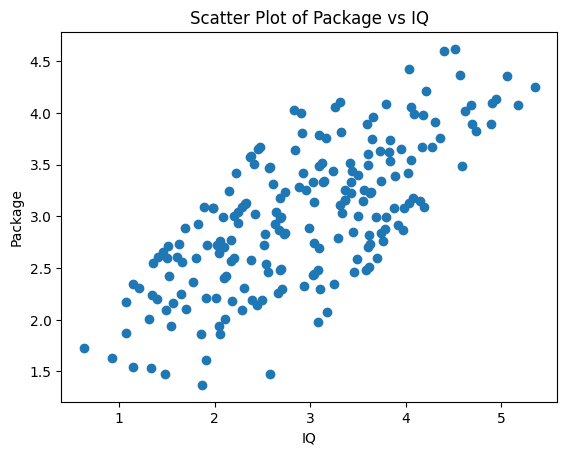

In [738]:
plt.scatter(df2['iq'],df2['package'])
plt.xlabel('IQ')
plt.ylabel('Package')
plt.title('Scatter Plot of Package vs IQ')
plt.show()

In [739]:
np.random.randint(-100,100) 

-94

In [740]:
X=df2.iloc[:, :-1]
y=df2.iloc[:,-1] 

In [741]:
X

,cgpa,iq
0,6.89,3.56
1,5.12,3.08
2,7.82,2.15
3,7.42,4.17
4,6.94,2.37
...,...,...
195,6.93,2.56
196,5.89,2.17
197,7.21,3.64
198,7.63,3.66


In [742]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [743]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [744]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [745]:
y_pred=lr.predict(X_test)

In [746]:
# R2 Score
r21 = r2_score(y_test, y_pred)
print("R2 Score:", r21)

R2 Score: 0.8264386105163523


In [747]:
# Adjusted R2 Score increased
R2_adj = 1 - (1 - r21) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score:", R2_adj)

Adjusted R2 Score: 0.8170569137875064


In [ ]:
len(y_test)  # total rows

40

In [750]:
X_test.shape[1] # total columns 

2